# Financial Trading with Python, 2nd Edition

Cordell L. Tanny, CFA, FRM, FDP

Chapter 13: Algorithmic Trading Strategies

Notebook 13.7: A Multi-Period Moving Average Strategy for Bitcoin

Version 1.0

Last revised: June 23, 2026

**Moving averages that fail on equities can still work, applied correctly to an asset whose fundamentals are genuinely hard to value.**

Before running anything, go to File and select Save a copy in Drive so you keep your own editable version.

This notebook depends on two files from the chapter: functions.py and vectorbt_harness.py. Drag both into the Colab session, into the file panel on the left, before running any cell. They reset when the runtime disconnects, so you will need to add them again at the start of each new session.

## 1.0 Introduction

Earlier in this chapter, the classic textbook moving-average rules came up short. A simple moving-average crossover, an RSI rule, a MACD signal: applied to broad equities, each one generated trades without generating an edge, and the costs of trading ate whatever small advantage the signal seemed to offer. That is the realistic outcome for most retail technical analysis, and it is worth seeing plainly rather than hearing about secondhand.

I did not want to end the moving-average discussion there. A signal failing on one asset does not mean the underlying idea is worthless; it can mean the idea was applied to the wrong asset. This notebook is the counterexample. We build a moving-average strategy that does work, and the reason it works is rooted in what kind of asset Bitcoin is.

The economic case comes from Detzel, Liu, Strauss, Zhou, and Zhu (2020), who show that prices predict future returns through their moving averages most strongly when an asset's fundamentals are hard to value. When there are no earnings, no dividends, and no analyst forecasts to anchor a price, investors learn the asset's value gradually from the price path itself, and that slow learning produces a measurable drift that moving averages can capture. Bitcoin is the cleanest example of a hard-to-value asset they study, and it is where their price-to-moving-average signal is strongest.

We will translate that finding into a working strategy. The signal compares Bitcoin's daily price against several of its own moving averages at once, counts how many of them the price sits above, and scales the position to that count. The more moving averages agree that the trend is up, the larger the allocation to Bitcoin, with the rest held in cash. We then run the result through the same backtest harness used across the chapter and judge it against the benchmark that makes this hard: buying Bitcoin and simply holding it.

In this notebook, we will cover:

- Pulling daily Bitcoin price history and computing a set of moving averages without leaking future information into the signal
- Turning the price-versus-moving-average comparison into a graded allocation that scales with agreement across windows
- Writing the sparse weights file the chapter harness expects, with one row per change in the target weight
- Backtesting the strategy after costs and measuring it against a buy-and-hold position in Bitcoin
- Reading the result for what it does and does not show about moving averages applied to the right asset

## 2.0 Setup and configuration

Every choice the strategy depends on lives in the configuration block below, so changing a window or a date is a single edit rather than a hunt through the notebook.

A few choices worth noting now:

- **MA windows [1, 2, 4, 10, 20]:** five lookback lengths in days. Each compares today's price against the average of the prior window and casts one vote. Short windows react fast, long windows react slowly, so the set blends quick and slow reads of the same price.
- **Single asset, BTC-USD:** the strategy holds Bitcoin or cash, nothing else. yfinance carries daily Bitcoin history, which is the only frequency this chapter uses.
- **Cash when out:** any fraction not in Bitcoin earns nothing. This is the conservative choice and matches the source paper, which holds the risk-free rate when out and which we set to zero.
- **Start date 2014-09-17:** the first day yfinance has BTC-USD. The strategy cannot trade an asset before its data begins.

Run the cell and check that the configuration prints back the values you expect before going further.

In [10]:
# =============================================================================
# CONFIGURATION
# =============================================================================
# All fixed choices for the strategy live here. Change a value once in this
# block and it propagates everywhere downstream.

!pip install vectorbt==0.28.5 pandas==2.2.2 numpy==2.0.2 yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from matplotlib.ticker import ScalarFormatter, NullFormatter
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# --- Asset and benchmark -----------------------------------------------------
# The strategy holds Bitcoin or cash. The benchmark is buy-and-hold Bitcoin,
# the hardest line to beat: the strategy has to earn its keep against simply
# owning the asset the whole way through.
TICKER = 'BTC-USD'
BENCHMARK = 'BTC-USD'

# --- Moving-average ensemble -------------------------------------------------
# Five lookback windows in DAYS. Each window compares the current price against
# its own moving average and casts one vote: long if price is above, flat if
# below. The position scales to how many windows vote long, so agreement across
# fast and slow windows drives the size. Taken directly from the source
# research (1, 2, 4, 10, and 20 weeks there; we apply the same counts in days
# on Bitcoin's daily calendar, matching the strategy we are replicating).
MA_WINDOWS = [1, 2, 4, 10, 20]

# --- Date range --------------------------------------------------------------
# Start at the first day yfinance has Bitcoin. End at a fixed date so the
# printed figures in the book stay reproducible.
START_DATE = '2014-09-17'
END_DATE = '2026-05-31'

# --- Quick confirmation ------------------------------------------------------
print("Configuration loaded.")
print(f"  Asset:            {TICKER}")
print(f"  Benchmark:        {BENCHMARK}")
print(f"  MA windows (days): {MA_WINDOWS}")
print(f"  Date range:       {START_DATE} to {END_DATE}")

Configuration loaded.
  Asset:            BTC-USD
  Benchmark:        BTC-USD
  MA windows (days): [1, 2, 4, 10, 20]
  Date range:       2014-09-17 to 2026-05-31


The configuration is set:

- Asset and benchmark are both BTC-USD, so the strategy is measured against simply holding Bitcoin.
- Five MA windows are active: 1, 2, 4, 10, and 20 days.
- The window runs from 2014-09-17 to 2026-05-31.

With the parameters fixed, the next step is to pull the price history and confirm it covers the full range.

## 3.0 Pulling the data

The strategy needs one thing: daily Bitcoin closing prices. The question this section answers is whether yfinance returns a clean, gap-free series over the full window.

We pull adjusted daily closes with auto_adjust=True so any splits or distributions are already folded in, then check three things in the output:

- The first and last dates match the configured range.
- The row count is close to the calendar length (Bitcoin trades every day, so roughly 365 rows per year).
- There are no missing values in the series.

In [2]:
# =============================================================================
# 3.0 Pull daily Bitcoin prices
# =============================================================================
# One asset, daily adjusted closes from yfinance. auto_adjust=True returns the
# adjusted close in the 'Close' field, so there is no separate 'Adj Close'
# column to reconcile. We keep a single tidy Series of closes indexed by date.

raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)

# With one ticker, 'Close' is a one-column frame. Pull it out as a Series and
# give it a clean name so everything downstream refers to the price by asset.
prices = raw['Close']
if isinstance(prices, pd.DataFrame):
    prices = prices.iloc[:, 0]
prices.name = TICKER

# --- Inspect what came back --------------------------------------------------
# Bitcoin trades 7 days a week, so a full year is about 365 rows, not 252.
# A large gap between expected and actual rows would point to a download
# problem worth investigating before building any signal on top of it.
n_days = (prices.index.max() - prices.index.min()).days + 1

print("Price history pulled.")
print(f"  Rows:        {len(prices)}")
print(f"  Date range:  {prices.index.min().date()} to {prices.index.max().date()}")
print(f"  Calendar days in range: {n_days}")
print(f"  Missing values: {int(prices.isna().sum())}")
print(f"\n  First 3 rows:")
print(prices.head(3).to_string())
print(f"\n  Last 3 rows:")
print(prices.tail(3).to_string())

[*********************100%***********************]  1 of 1 completed

Price history pulled.
  Rows:        4274
  Date range:  2014-09-17 to 2026-05-30
  Calendar days in range: 4274
  Missing values: 0

  First 3 rows:
Date
2014-09-17    457.334015
2014-09-18    424.440002
2014-09-19    394.795990

  Last 3 rows:
Date
2026-05-28    73536.554688
2026-05-29    73372.523438
2026-05-30    73754.835938


The pull is complete and gap-free:

- 4,274 daily closes, exactly one per calendar day in the range, confirming Bitcoin's 7-day-a-week trading with no missing dates.
- The series runs 2014-09-17 to 2026-05-30, the full configured window.
- No missing values, so nothing needs filling or interpolating before we build the signal.

The price moves from about \$457 at the start to roughly $73,750 at the end. That climb is the benchmark the strategy has to contend with: buy-and-hold Bitcoin set a very high bar, and the rest of the notebook asks whether timing the position with moving averages can do better on a risk-adjusted basis.

## 4.0 Building the signal

The signal turns one price series into a daily target weight for Bitcoin. The recipe has three steps, and the order matters for keeping future information out:

1. **Moving averages, lagged.** For each window, average the prior days' prices, excluding today. Shifting back one day before averaging means today's price is never part of the average it gets compared against.
2. **Votes.** Each window votes long when today's price sits above its moving average, flat otherwise. Five windows give a vote count from 0 to 5.
3. **Weight.** Divide the vote count by 5. The target Bitcoin weight steps through 0, 0.2, 0.4, 0.6, 0.8, 1.0 as more windows agree the trend is up.

The longest window is 20 days, so the first 20 rows cannot produce a complete set of averages. We drop that warmup before going further. Look in the output for the first valid signal date and a weight column that only ever takes the six expected values.

In [4]:
# =============================================================================
# 4.0 Build the signal: price vs moving averages -> graded weight
# =============================================================================
# Three steps, matching the strategy we are replicating:
#   1. moving averages computed on PRIOR days only (today excluded)
#   2. one long/flat vote per window (price above its average = long)
#   3. target weight = votes / number of windows

# --- Step 1: lagged moving averages -----------------------------------------
# shift(1) drops today's price out before the rolling mean, so each window
# averages only days that closed BEFORE today. This is what keeps the signal
# honest: the average a price is compared against never contains that price,
# so we cannot accidentally use information from the day we are trading on.
ma = pd.DataFrame(index=prices.index)
for w in MA_WINDOWS:
    ma[f'MA_{w}'] = prices.shift(1).rolling(window=w).mean()

# --- Step 2: one vote per window --------------------------------------------
# A window votes long (1) when today's price is above its lagged average,
# flat (0) otherwise. Summing across windows gives a 0-to-5 agreement count.
votes = pd.DataFrame(index=prices.index)
for w in MA_WINDOWS:
    votes[f'vote_{w}'] = (prices > ma[f'MA_{w}']).astype(int)
vote_count = votes.sum(axis=1)

# --- Step 3: graded target weight -------------------------------------------
# Scale the count to a weight in [0, 1]. With five windows the weight can only
# be 0, 0.2, 0.4, 0.6, 0.8, or 1.0: more agreement means a larger position.
target_weight = vote_count / len(MA_WINDOWS)

# --- Drop the warmup --------------------------------------------------------
# The longest window needs 20 prior closes, so the earliest rows have an
# incomplete average and a meaningless vote. Drop every row until all five
# moving averages exist (the longest window is the binding constraint).
signal = pd.DataFrame({
    'price': prices,
    'vote_count': vote_count,
    'target_weight': target_weight,
})
signal = signal.loc[ma.dropna().index]

print("Signal built.")
print(f"  Rows after warmup drop: {len(signal)}")
print(f"  First valid signal date: {signal.index.min().date()}")
print(f"  Unique target weights: {sorted(signal['target_weight'].unique())}")
print(f"\n  First 5 rows:")
print(signal.head(5).round(4).to_string())
print(f"\n  Weight distribution (share of days at each level):")
print((signal['target_weight'].value_counts(normalize=True).sort_index().round(3)).to_string())

Signal built.
  Rows after warmup drop: 4254
  First valid signal date: 2014-10-07
  Unique target weights: [np.float64(0.0), np.float64(0.2), np.float64(0.4), np.float64(0.6), np.float64(0.8), np.float64(1.0)]

  First 5 rows:
              price  vote_count  target_weight
Date                                          
2014-10-07  336.187           3            0.6
2014-10-08  352.940           3            0.6
2014-10-09  365.026           4            0.8
2014-10-10  361.562           3            0.6
2014-10-11  362.299           3            0.6

  Weight distribution (share of days at each level):
target_weight
0.0    0.206
0.2    0.118
0.4    0.133
0.6    0.136
0.8    0.126
1.0    0.280


The signal is built and behaves as designed:

- 4,254 rows survive the warmup, with the first valid signal on 2014-10-07, exactly 20 days after the price history begins.
- The target weight only ever takes the six expected values: 0, 0.2, 0.4, 0.6, 0.8, 1.0.

The weight distribution shows the strategy is not shy about taking sides:

- **Fully out (0.0):** 20.6% of days
- **Fully in (1.0):** 28.0% of days
- **Partial (0.2 to 0.8):** the remaining 51.4%, fairly evenly spread

Bitcoin spends a little over a quarter of the sample with every window in agreement that the trend is up, and about a fifth of the sample fully in cash with no window voting long. The strategy holds some Bitcoin on roughly four days in five, which is what we would expect for an asset that trended upward over most of this period.

## 5.0 Backtesting the strategy

### 5.1 Build the sparse weights file

The harness reads a sparse weights file: one row per trade, dated to the day the position changes, with the weight held until the next dated row. Between rows the harness holds, so we only write a row when the target weight actually changes.

The daily signal repeats the same weight for stretches at a time. Writing every day would charge fees and slippage on rebalances that do not move the position. Instead we keep only the rows where the weight differs from the day before, which is the correct sparse form and keeps trading costs realistic.

Checks to look for in the output:

- The first sparse row matches the first signal date, so the position is established at the start.
- The number of sparse rows is far smaller than 4,254, confirming the weight is stable for long stretches.
- The single column is the bare ticker BTC-USD, and the index is named date, which is the format the harness expects.

In [5]:
# =============================================================================
# 5.1 Build the sparse weights file
# =============================================================================
# The harness contract: one row per trade date, weight held until the next
# dated row, NaN-free, columns are bare tickers, index named 'date'. We keep
# only the days the target weight CHANGES, so the file is sparse and the
# backtest is not charged for rebalances that leave the position untouched.

# Single-column weight frame: the target Bitcoin weight, the rest is cash.
# Cash is implicit here: a weight below 1.0 means the harness leaves the
# remainder uninvested, which is exactly the "hold cash when out" rule.
weights_full = signal[['target_weight']].copy()
weights_full.columns = [TICKER]

# --- Keep only change days --------------------------------------------------
# A row is kept if its weight differs from the previous row's weight. The first
# row is always kept so the position is established at the start of the window.
# .shift() compares each weight to the day before; the first row compares
# against NaN and so is flagged as a change, which is what we want.
is_change = weights_full[TICKER] != weights_full[TICKER].shift()
weights = weights_full[is_change].copy()

# --- Sanity checks before handing it to the harness -------------------------
# No missing values: warmup was dropped upstream, so this should hold.
assert not weights.isna().any().any(), "Weights contain NaN; check the warmup drop."

# Weights bounded in [0, 1]: a single asset plus cash, no leverage, no shorts.
assert (weights[TICKER] >= 0).all() and (weights[TICKER] <= 1).all(), \
    "Weight outside [0, 1]; check the vote-to-weight step."

# Consecutive rows must differ: that is the definition of sparse-on-change.
assert (weights[TICKER].diff().fillna(1) != 0).all(), \
    "Found a repeated weight; change-day filter did not work."

# Write the file with the date index and bare ticker column the harness reads.
weights_path = 'btc_ma_weights.csv'
weights.index.name = 'date'
weights.to_csv(weights_path, float_format='%.6f')

print("Sparse weights file written.")
print(f"  Path: {weights_path}")
print(f"  Sparse rows (trades): {weights.shape[0]}")
print(f"  Signal days covered:  {len(signal)}")
print(f"  Column: {list(weights.columns)}")
print(f"  Date range: {weights.index.min().date()} to {weights.index.max().date()}")
print(f"\n  First 5 rows:")
print(weights.head(5).to_string())
print(f"\n  Last 5 rows:")
print(weights.tail(5).to_string())

Sparse weights file written.
  Path: btc_ma_weights.csv
  Sparse rows (trades): 2971
  Signal days covered:  4254
  Column: ['BTC-USD']
  Date range: 2014-10-07 to 2026-05-30

  First 5 rows:
            BTC-USD
date               
2014-10-07      0.6
2014-10-09      0.8
2014-10-10      0.6
2014-10-12      1.0
2014-10-15      0.6

  Last 5 rows:
            BTC-USD
date               
2026-05-23      0.4
2026-05-24      0.6
2026-05-25      0.8
2026-05-26      0.0
2026-05-30      0.4


The weights file is written and passes every check, but the trade count deserves attention:

- 2,971 sparse rows across 4,254 signal days, so the target weight changes on roughly 7 days out of 10.
- The position is established on the first signal date, 2014-10-07, and the column and index are in the format the harness reads.

The file is technically sparse, but only just. The daily vote count is jittery, so the graded weight rarely holds still for long. The early rows show the pattern plainly: the weight steps 0.6, 0.8, 0.6, 1.0, 0.6 over the first week, each step a small rebalance.

This matters for one reason: the harness charges fees and slippage on every one of those 2,971 rebalances. Many are minor adjustments, a fifth of the position in or out, that each pay the toll. The question for the next cell is whether the signal's edge is large enough to clear that cost drag. The after-costs column is the one that settles it.

### 5.2 Running the backtest

We hand the weights file to the harness and let it do the rest: download prices, align them to the weights, place the trades on the calendar, and run the portfolio twice, once with no costs and once with costs applied. Both are scored on monthly returns against buy-and-hold Bitcoin.

A note on fees before reading the result. The harness charges 10 bps commission and 5 bps slippage on every rebalance, the chapter-standard figures used by every other strategy here so the comparison stays consistent. For Bitcoin that is a fair taker rate on a major exchange, and limit orders on the same venues can reach zero, so 10 bps sits at the conservative end. It also charges on all 2,971 rebalances, including the many small 0.2 steps, so the after-costs figure carries a heavy and somewhat artificial drag from the trade count.

That is why the focus of this notebook is the no-cost result. The goal is not to present a deployable system tuned for costs; it is to show that a moving-average approach, used in a graded multi-window form on an asset suited to it, can generate a real edge where the textbook equity rules could not. The no-cost column isolates that edge, which is the lesson. The after-costs column is shown for consistency and as a realistic caution, and the gap between the two is itself worth reading.

Look for two things in the output:

- Whether the no-cost strategy beats buy-and-hold Bitcoin on risk-adjusted terms (Sharpe, drawdown), not just raw return.
- How much of that edge the costs consume.

In [6]:
# =============================================================================
# 5.2 Run the backtest through the harness
# =============================================================================
# The harness is imported as a module. It handles the price download, column
# alignment, calendar placement, the no-cost and after-costs portfolio runs,
# and the scoring. We pass the weights file and the benchmark; everything else
# uses the chapter-standard defaults (10 bps fees, 5 bps slippage, monthly
# scoring at 12 periods per year).

from vectorbt_harness import run_backtest

result = run_backtest(
    'btc_ma_weights.csv',
    benchmark=BENCHMARK,   # buy-and-hold Bitcoin, the hardest line to beat
    fees=0.0010,           # 10 bps commission per rebalance (conservative taker rate)
    slippage=0.0005,       # 5 bps slippage per rebalance
    init_cash=10_000,
    periods_per_year=12,   # monthly scoring, matching the rest of the chapter
    verbose=True,
)

# result.metrics holds the scored table: no-cost, after-costs, and benchmark.
# We read it in the next cell and then plot the equity curve.

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Backtest start: 2014-10-07
Backtest end:   2026-06-05
Trading days:   4260
Trades in window: 2971

Harness evaluation (monthly metrics)
                        Strategy No Cost Strategy w/ Costs BTC-USD Buy & Hold
Total Return                   24174.76%          4869.57%          18021.66%
Ann. Return (CAGR)                59.58%            39.43%             55.66%
Ann. Volatility                   51.75%            50.92%             71.46%
Downside Deviation                17.40%            19.30%             34.36%
Max Drawdown                     -53.32%           -63.11%            -75.57%
Max DD Duration (days)                34                63                 34
Ulcer Index                       18.830            28.190             35.413
Sharpe Ratio                       1.151             0.774              0.779
Sortino Ratio                      3.425             2.043              1.620
Calmar Ratio                       1.118             0.625              0.737
Ulcer 

The no-cost result is the one to read first, and it makes the case the notebook set out to make. Against buy-and-hold Bitcoin, the strategy with no costs:

- **Higher return:** 59.6% CAGR versus 55.7% for buy-and-hold, so timing did not cost return even before accounting for risk.
- **Far less risk:** annual volatility of 51.8% versus 71.5%, and a max drawdown of -53.3% versus -75.6%.
- **Better risk-adjusted scores across the board:** Sharpe 1.15 versus 0.78, Sortino 3.43 versus 1.62, Calmar 1.12 versus 0.74.

That is the result the textbook equity rules could not produce earlier in the chapter. The same family of signal, moving averages of price, applied to an asset whose fundamentals are hard to value, both raised return and cut risk against simply holding the asset. The edge shows up most clearly in the downside numbers: the strategy sidesteps part of Bitcoin's worst declines by scaling down when the windows stop agreeing.

Now the costs. The after-costs column pays for all 2,971 rebalances, and the drag is heavy:

- CAGR falls from 59.6% to 39.4%.
- Sharpe falls from 1.15 to 0.77, landing right on top of buy-and-hold's 0.78.

So after costs the timing edge is almost exactly consumed by the trade count, and the strategy ends up risk-adjusted even with simply holding Bitcoin, though still with a noticeably smaller drawdown (-63.1% versus -75.6%). The gap between the two columns is the real takeaway: the signal contains a genuine edge, but capturing it at this trade frequency requires either cheaper execution (maker orders near zero bps) or a less twitchy version of the weight that trades less often. The negative information ratios reflect the same thing, the strategy's monthly returns track Bitcoin closely, so its value is in the risk reduction rather than in beating Bitcoin month to month.

## 6.0 Visualizing the results

Two pictures close out the analysis:

- The first puts the equity curves side by side, no-cost strategy, after-costs strategy, and buy-and-hold Bitcoin, on the monthly basis used for scoring. This is where the risk reduction becomes visible: watch the strategy curves during Bitcoin's deep drawdowns.
- The second shows the target weight over time against the Bitcoin price, so you can see the signal scaling in during trends and stepping out during declines.

Both are drawn in grayscale with distinct line styles for the print book.

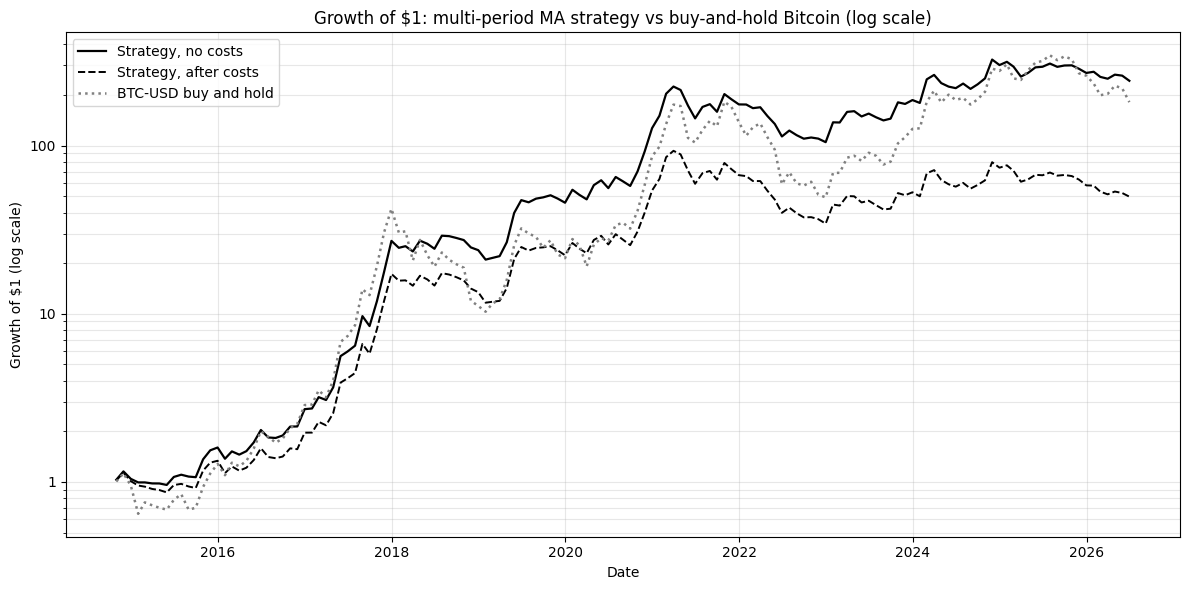

In [11]:
# =============================================================================
# 6.0 Figure 1: equity curves, monthly, grayscale-safe
# =============================================================================
# Three curves on the monthly basis used for scoring: the no-cost strategy,
# the after-costs strategy, and buy-and-hold Bitcoin. Distinct line styles and
# greyscale so the figure reads in the printed book.

from vectorbt_harness import to_monthly

# Pull monthly returns for each line from the harness result, aligned to the
# benchmark window so all three cover the same months.
bench_daily = result.bench_returns
common = result.pf_no_cost.returns().index.intersection(bench_daily.index)

strat_nc_m = to_monthly(result.pf_no_cost.returns().loc[common])
strat_wc_m = to_monthly(result.pf_costs.returns().loc[common])
bench_m = to_monthly(bench_daily.loc[common])

# Growth of $1 for each line.
curve_nc = (1 + strat_nc_m).cumprod()
curve_wc = (1 + strat_wc_m).cumprod()
curve_bh = (1 + bench_m).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))

# Log scale: Bitcoin spans several orders of magnitude over the window, so a
# linear axis would flatten the entire early history into the floor.
ax.set_yscale('log')

# Plain numbers on the major ticks (1, 10, 100), no scientific notation, and
# no minor-tick labels so the low end of the axis stays readable.
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())

ax.plot(curve_nc.index, curve_nc.values, color='black',
        linestyle='-', linewidth=1.6, label='Strategy, no costs')
ax.plot(curve_wc.index, curve_wc.values, color='black',
        linestyle='--', linewidth=1.4, label='Strategy, after costs')
ax.plot(curve_bh.index, curve_bh.values, color='gray',
        linestyle=':', linewidth=1.8, label='BTC-USD buy and hold')

ax.set_title('Growth of $1: multi-period MA strategy vs buy-and-hold Bitcoin (log scale)')
ax.set_xlabel('Date')
ax.set_ylabel('Growth of $1 (log scale)')
ax.legend(loc='upper left')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

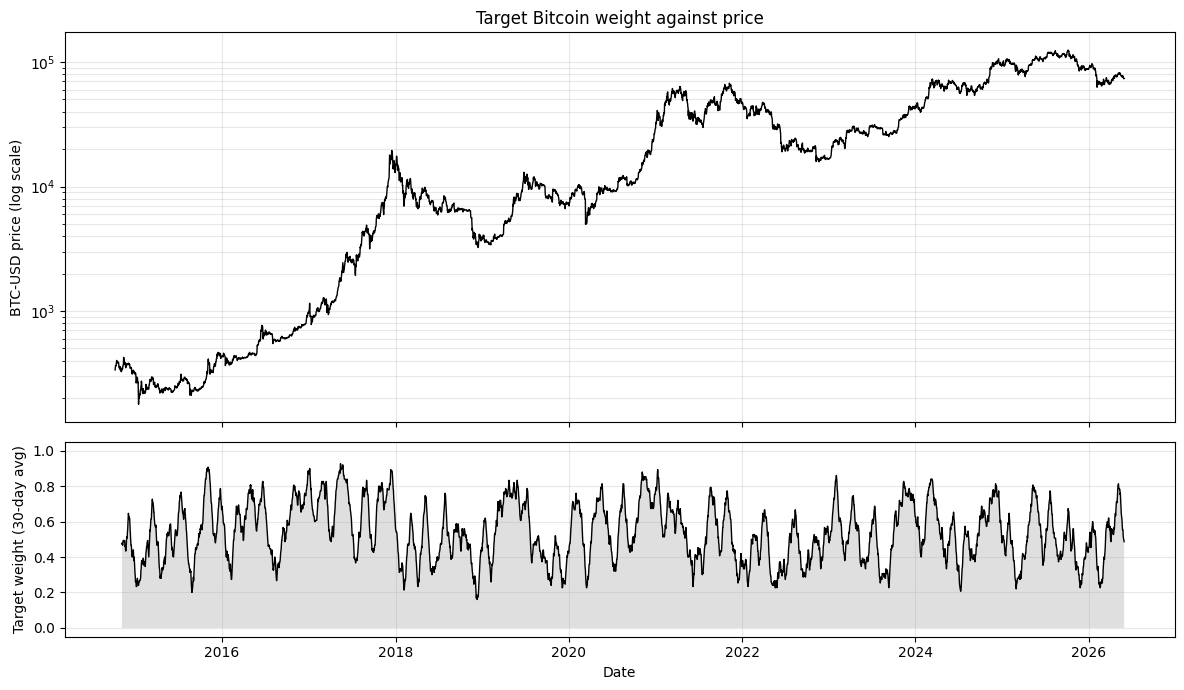

In [13]:
# =============================================================================
# 6.0 Figure 2: target weight against Bitcoin price, grayscale-safe
# =============================================================================
# The signal in action: the Bitcoin price on a log axis with the daily target
# weight beneath it. Where the weight steps down, the strategy is scaling out
# of a falling or uncertain market; where it holds at 1.0, every window agrees.

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 7), sharex=True,
    gridspec_kw={'height_ratios': [2, 1]},
)

# Top: Bitcoin price over the signal window, log scale for the same reason as
# the equity figure.
sig_price = signal['price']
ax1.plot(sig_price.index, sig_price.values, color='black', linewidth=1.0)
ax1.set_yscale('log')
ax1.set_ylabel('BTC-USD price (log scale)')
ax1.set_title('Target Bitcoin weight against price')
ax1.grid(True, which='both', alpha=0.3)

# Bottom: the target weight is too jittery to plot raw at daily frequency, so
# we show a 30-day rolling average of it. The smoothed line reads as "how much
# of the time the strategy was holding Bitcoin" over the prior month, which is
# the trend a reader needs against the price above, rather than 2,971
# individual daily steps that smear into a solid block.
weight_smooth = signal['target_weight'].rolling(window=30).mean()

ax2.plot(weight_smooth.index, weight_smooth.values,
         color='black', linewidth=1.0)
ax2.fill_between(weight_smooth.index, weight_smooth.values, 0,
                 facecolor='gray', alpha=0.25)
ax2.set_ylim(-0.05, 1.05)
ax2.set_ylabel('Target weight (30-day avg)')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The two figures together show where the edge comes from and what it does not do.

The equity curves (Figure 1, log scale so the early years are visible):

- The no-cost strategy tracks buy-and-hold closely on the way up but pulls ahead through the drawdowns, ending higher with a smoother path.
- The after-costs curve sits well below both, the visible price of trading on roughly 7 days in 10.
- All three finish far above where they started, so this is a question of how much risk was taken to get there, not whether Bitcoin rose.

The weight against price (Figure 2, weight smoothed to a 30-day average):

- The strategy does not cleanly step aside during crashes. Through the 2018 and 2022 declines the smoothed weight dips toward 0.2 to 0.3 but keeps bouncing rather than going flat.
- Its average exposure is lower in falling and choppy markets and higher in sustained uptrends, which is enough to cut volatility and drawdown over the full run.

So the risk reduction is real but undramatic. It comes from the strategy carrying less Bitcoin on average through bad stretches, not from calling tops and sitting in cash. That is the realistic version of what a moving-average signal does: it leans with the trend and trims against it, and on an asset suited to the signal that lean is worth a meaningful improvement in risk-adjusted return before costs.

## 7.0 Summary

This notebook closed the moving-average thread of the chapter by answering the question the earlier failures left open: are moving averages useless, or were they just pointed at the wrong asset?

What we built:

- A multi-window signal that compares Bitcoin's daily price against five of its own moving averages (1, 2, 4, 10, and 20 days), counts the windows voting long, and scales the position to that count.
- A sparse weights file written on change days only, fed to the chapter harness and scored against the hardest benchmark available, buy-and-hold Bitcoin.

What the result showed, before costs:

- Higher return than buy-and-hold (59.6% versus 55.7% CAGR) with far less risk (volatility 51.8% versus 71.5%, max drawdown -53.3% versus -75.6%).
- Better on every risk-adjusted measure: Sharpe 1.15 versus 0.78, Sortino 3.43 versus 1.62.

That is the payoff the chapter was building toward. The same family of signal that could not beat costs on broad equities produced a genuine edge on Bitcoin, exactly where the research of Detzel, Liu, Strauss, Zhou, and Zhu (2020) says it should: an asset with no earnings or dividends to anchor it, where price drift from gradual learning is strongest.

What the result also showed, after costs:

- The graded weight changes on roughly 7 days in 10, and charging fees and slippage on all 2,971 rebalances cut the Sharpe from 1.15 to 0.77, landing on top of buy-and-hold.
- The edge is real but trades too often to survive standard costs as written. Capturing it would need cheaper execution or a less twitchy version of the weight.

The wider lesson carries past this one strategy. A signal that fails is not proof the idea is empty; it can be proof the idea was tested on the wrong asset or implemented without regard for trading costs. Matching a technique to an asset whose behavior fits it, then checking whether the edge survives realistic frictions, is the discipline that separates a backtest worth trusting from one that only looks good on paper.

This brings the algorithmic trading strategies chapter to a close. The next chapter moves from rules we specify by hand to models that learn their own, introducing machine learning for signal generation and the new ways it can go wrong.

References:
Detzel, Andrew, Hong Liu, Jack Strauss, Guofu Zhou, and Yingzi Zhu. 2020. "Learning and Predictability via Technical Analysis: Evidence from Bitcoin and Stocks with Hard-to-Value Fundamentals." Working paper, January 29, 2020. SSRN 3115846.
https://ssrn.com/abstract=3115846